# Import Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Master Dataset

Load the master dataset generated during the preprocessing stage. This dataset contains the merged sustainability reports, ESG information, and generated claim features.

In [16]:
merged = pd.read_csv("Master_Dataset.csv")

# Remove unnecessary index column if it exists
if "Unnamed: 0" in merged.columns:
    merged = merged.drop(columns=["Unnamed: 0"])

print(merged.head())

           filename ticker  year  \
0  ASX_BSX_2020.pdf    BSX  2020   
1  ASX_BSX_2022.pdf    BSX  2022   
2  ASX_EXR_2022.pdf    EXR  2022   
3  LSE_ADM_2019.pdf    ADM  2019   
4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'mongolia', 'australia', 'austra...     3.81     4.28   
3  ['david stevens', 'csr board', 'just over  yea...    16.38    14.20   
4  ['year', 'health & wellbeing', 'a -month', 'on...    15.89    13.51   

 

# Calculate Greenwashing Risk Score

In [18]:
commitment_keywords = [
    "commitment", "future", "goal", "vision", "ambition",
    "pledge", "aspiration", "promise", "target"
]

action_keywords = [
    "reduced", "reduction", "achieved", "implemented",
    "completed", "installed", "decreased", "improved",
    "delivered", "measured", "verified", "audited"
]

def count_words(text, words):
    text = str(text).lower()
    count = 0
    for word in words:
        count += text.count(word)
    return count

merged['commitment_score'] = merged['preprocessed_content'].apply(
    lambda x: count_words(x, commitment_keywords)
)

merged['action_score'] = merged['preprocessed_content'].apply(
    lambda x: count_words(x, action_keywords)
)

merged['alignment_score'] = (
    merged['action_score'] /
    (merged['commitment_score'] + 1)
)

merged['greenwashing_score'] = (
    merged['vague_count'] *
    merged['Total ESG Risk score']
) / (merged['alignment_score'] + 1)

print(
    merged[
        [
            'ticker',
            'vague_count',
            'Total ESG Risk score',
            'alignment_score',
            'greenwashing_score'
        ]
    ].head()
)

  ticker  vague_count  Total ESG Risk score  alignment_score  \
0    BSX          101                  23.1         0.027027   
1    BSX          120                  23.1         0.169811   
2    EXR            4                  15.2         0.125000   
3    ADM           29                  31.8         0.190476   
4    ADM           72                  31.8         0.140000   

   greenwashing_score  
0         2271.702632  
1         2369.612903  
2           54.044444  
3          774.648000  
4         2008.421053  


# Create Greenwashing Risk Ranking Table

In [19]:
top_greenwashing = merged.sort_values(
    by='greenwashing_score',
    ascending=False
)

print(
    top_greenwashing[
        [
            'ticker',
            'Name',
            'greenwashing_score'
        ]
    ].head(10)
)

    ticker                                     Name  greenwashing_score
632    MMM                               3m Company        20735.325182
631    MMM                               3m Company        19560.455910
654    NEM                      Newmont Corporation        13836.959510
491    FCX                    Freeport-Mcmoran Inc.        13611.516279
492    FCX                    Freeport-Mcmoran Inc.        13004.512676
633    MMM                               3m Company        12755.909259
653    NEM                      Newmont Corporation        12373.240248
795    UHS  Universal Health Services, Inc. Class B        10554.269874
557    ITW                 Illinois Tool Works Inc.        10535.753049
652    NEM                      Newmont Corporation        10455.529821


In [20]:
top_greenwashing_unique = (
    top_greenwashing
    .drop_duplicates(subset=['ticker'])
)

print(
    top_greenwashing_unique[
        [
            'ticker',
            'Name',
            'greenwashing_score'
        ]
    ].head(10)
)

    ticker                                     Name  greenwashing_score
632    MMM                               3m Company        20735.325182
654    NEM                      Newmont Corporation        13836.959510
491    FCX                    Freeport-Mcmoran Inc.        13611.516279
795    UHS  Universal Health Services, Inc. Class B        10554.269874
557    ITW                 Illinois Tool Works Inc.        10535.753049
428    COP                           Conocophillips         9810.794702
720    SHW             The Sherwin-Williams Company         9510.622642
286    ABT                      Abbott Laboratories         8821.405091
565    JCI       Johnson Controls International Plc         8562.791489
647    MTB                           M&t Bank Corp.         8509.444444


In [21]:
rq5_table = top_greenwashing_unique[
    [
        'ticker',
        'Name',
        'greenwashing_score'
    ]
].head(10)

print(rq5_table)

    ticker                                     Name  greenwashing_score
632    MMM                               3m Company        20735.325182
654    NEM                      Newmont Corporation        13836.959510
491    FCX                    Freeport-Mcmoran Inc.        13611.516279
795    UHS  Universal Health Services, Inc. Class B        10554.269874
557    ITW                 Illinois Tool Works Inc.        10535.753049
428    COP                           Conocophillips         9810.794702
720    SHW             The Sherwin-Williams Company         9510.622642
286    ABT                      Abbott Laboratories         8821.405091
565    JCI       Johnson Controls International Plc         8562.791489
647    MTB                           M&t Bank Corp.         8509.444444


# Visualize Greenwashing Risk Ranking

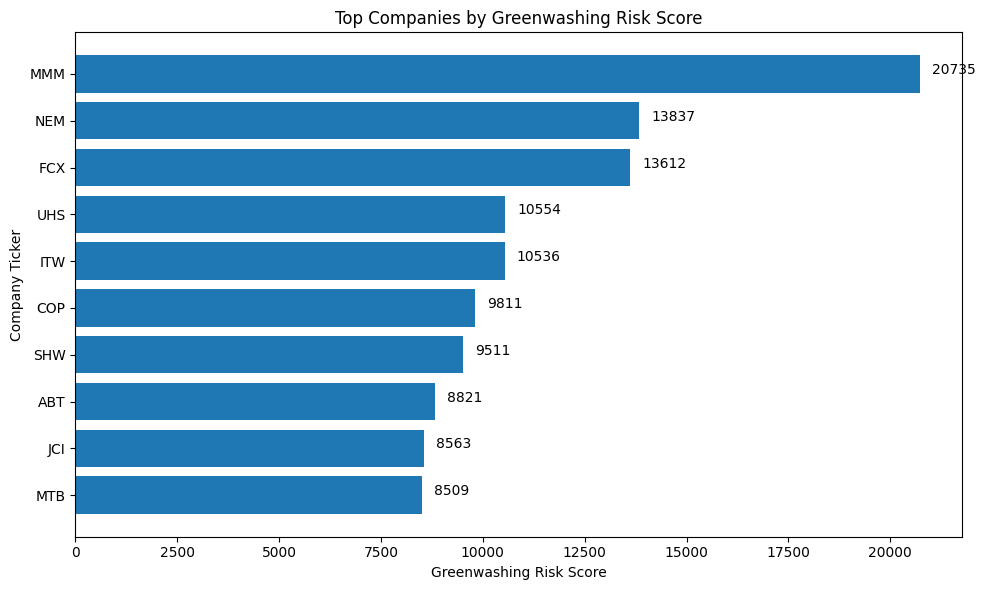

In [22]:
top10 = rq5_table.sort_values(
    by='greenwashing_score',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['ticker'],
    top10['greenwashing_score']
)

plt.xlabel("Greenwashing Risk Score")
plt.ylabel("Company Ticker")
plt.title("Top Companies by Greenwashing Risk Score")

for i, value in enumerate(top10['greenwashing_score']):
    plt.text(value + 300, i, f"{value:.0f}")

plt.tight_layout()

plt.savefig(
    "RQ5_Top_Greenwashing_Companies.pdf",
    bbox_inches="tight"
)

plt.show()

# Save Figure and Table

In [23]:
# Save table
rq5_table.to_csv(
    "RQ5_Top_Greenwashing_Companies.csv",
    index=False
)

# Save figure
plt.savefig(
    "RQ5_Top_Greenwashing_Companies.pdf",
    bbox_inches='tight'
)

print("RQ5 outputs saved successfully.")

RQ5 outputs saved successfully.


<Figure size 640x480 with 0 Axes>